Data Understanding and Visualization

In [1]:
import zipfile
import os

zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction Done!")


print(os.listdir("/content"))
print(os.listdir("/content/FruitinAmazon"))

✅ Extraction Done!
['.config', 'FruitinAmazon', 'FruitinAmazon.zip', 'sample_data']
['test', 'train']


In [2]:
import os

# Define dataset path
train_dir = "/content/FruitinAmazon/train"


class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Check for Corrupted Images

In [3]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
        os.remove(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


Count Class Balance

In [4]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


 Visualize Random Images from Each Class

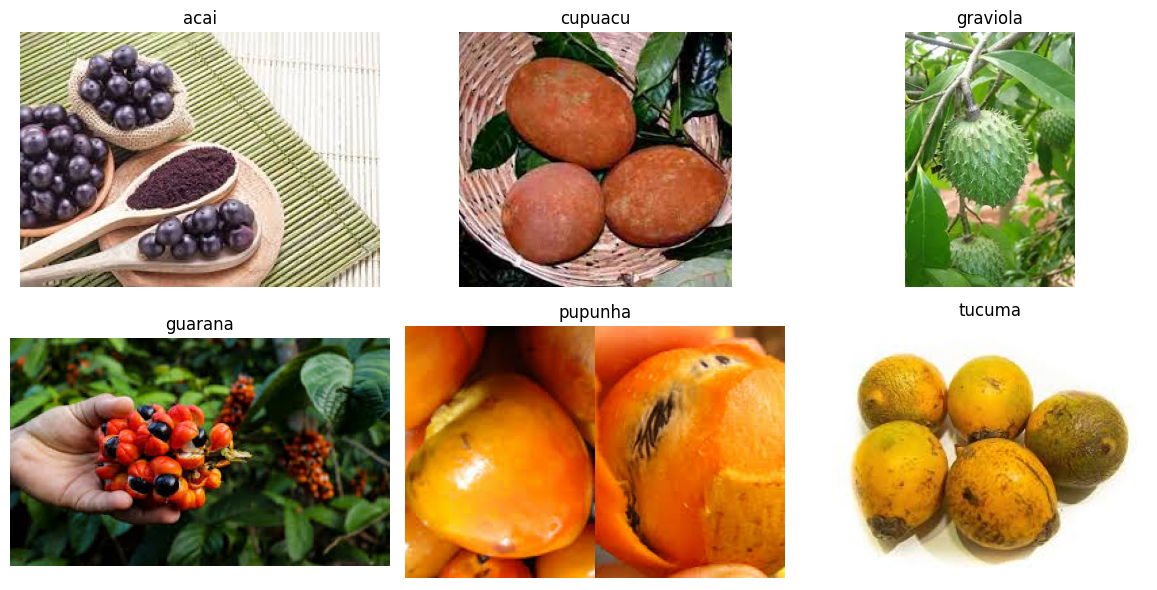

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

 Data Generation & Pre-processing

 Generate Train and Validation Dataset

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define image size and batch size
image_size = (224, 224)
batch_size = 32

# Load dataset and split 20% for validation
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

print("Class Names:", train_ds.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Check Batch Shape

In [7]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


Visualize Training Dataset

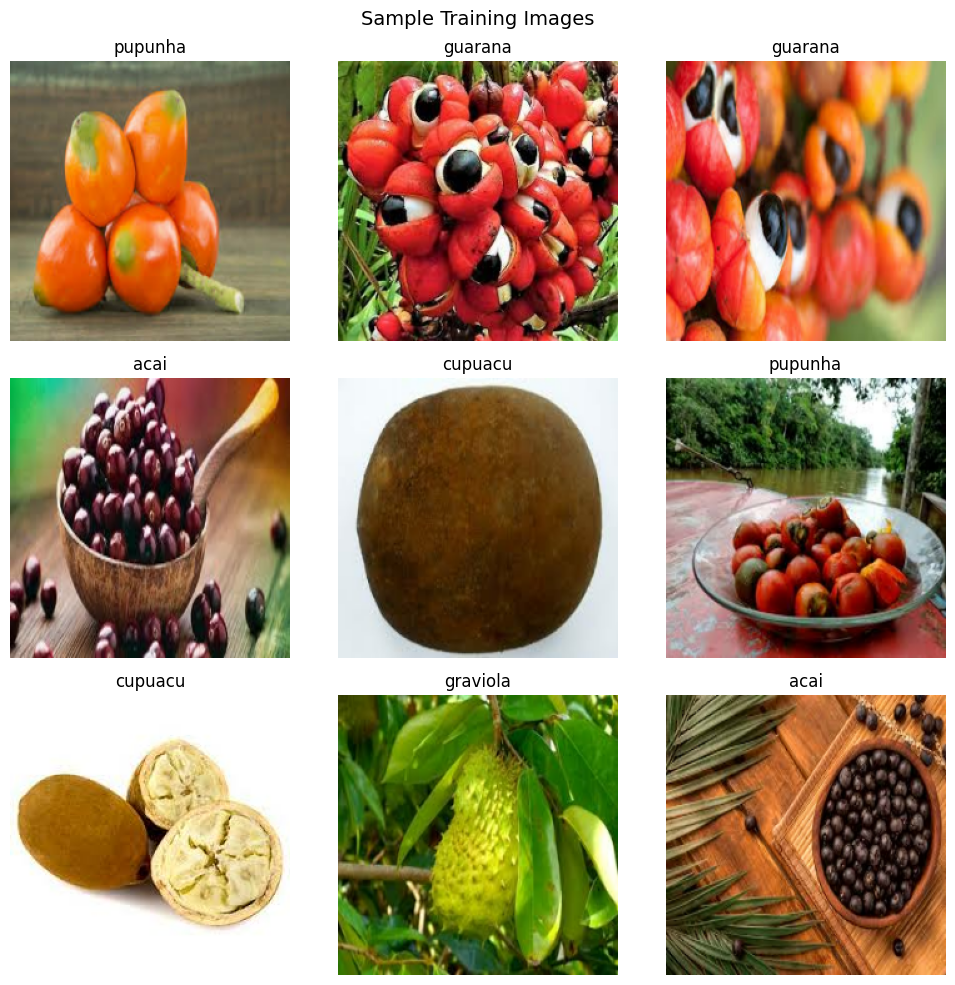

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

Visualize Augmented Images

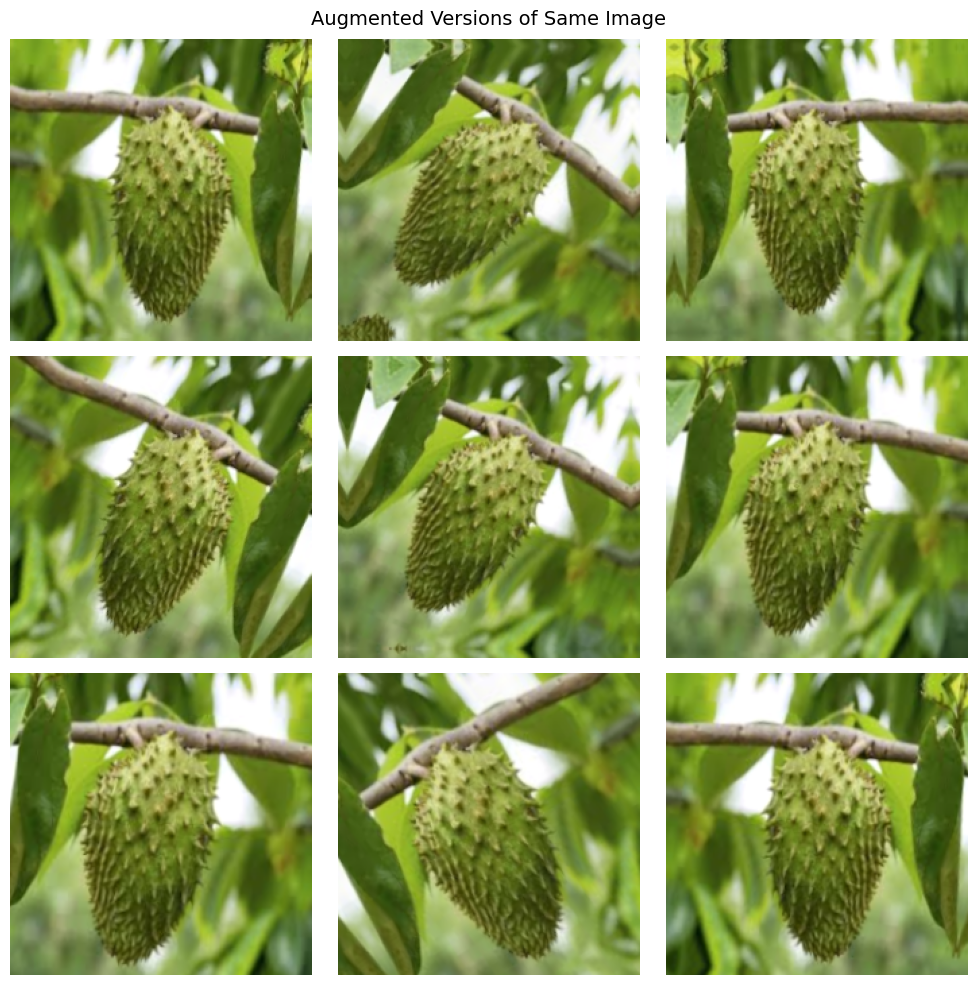

In [22]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

plt.suptitle("Augmented Versions of Same Image", fontsize=14)
plt.tight_layout()
plt.show()

Data Augmentation

In [25]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

CNN Model from Scratch

 Build the CNN Model with BatchNormalization and Dropout

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

num_classes = len(class_names)

model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(512),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    Dense(256),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

Compile and Train the Model

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,32

 Total params: 51,610,822 (196.88 MB)

 Trainable params: 51,608,838 (196.87 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.1667 - loss: 2.2708 - val_accuracy: 0.2778 - val_loss: 1.6698
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.4861 - loss: 1.3151 - val_accuracy: 0.2778 - val_loss: 1.6805
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5556 - loss: 1.2003 - val_accuracy: 0.1667 - val_loss: 1.8277
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.5556 - loss: 1.1430 - val_accuracy: 0.0556 - val_loss: 2.0803
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6944 - loss: 0.9903 - val_accuracy: 0.0556 - val_loss: 2.3503
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.7361 - loss: 0.7206 - val_accuracy: 0.1111 - val_loss: 2.5304
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.7083 - loss: 0.7223 - val_accuracy: 0.1111 - val_loss: 2.7583
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.7778 - loss: 0.6417 - val_accuracy: 0.1111 - val_loss: 2.9922
Epoch 9/

Train the Model

In [23]:
EPOCHS = 30

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.9167 - loss: 0.2469 - val_accuracy: 0.0556 - val_loss: 5.3375
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.9444 - loss: 0.2313 - val_accuracy: 0.0556 - val_loss: 5.4046
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9583 - loss: 0.1613 - val_accuracy: 0.0556 - val_loss: 5.4992
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.9444 - loss: 0.2086 - val_accuracy: 0.0556 - val_loss: 5.5671
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9583 - loss: 0.1905 - val_accuracy: 0.0556 - val_loss: 5.6114
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9306 - loss: 0.1975 - val_accuracy: 0.0556 - val_loss: 5.6322
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.9583 - loss: 0.1713 - val_accuracy: 0.0556 - val_loss: 5.6844
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.9583 - loss: 0.1189 - val_accuracy: 0.0556 - val_loss: 5.7290
Epoch 9/

Plot Training History

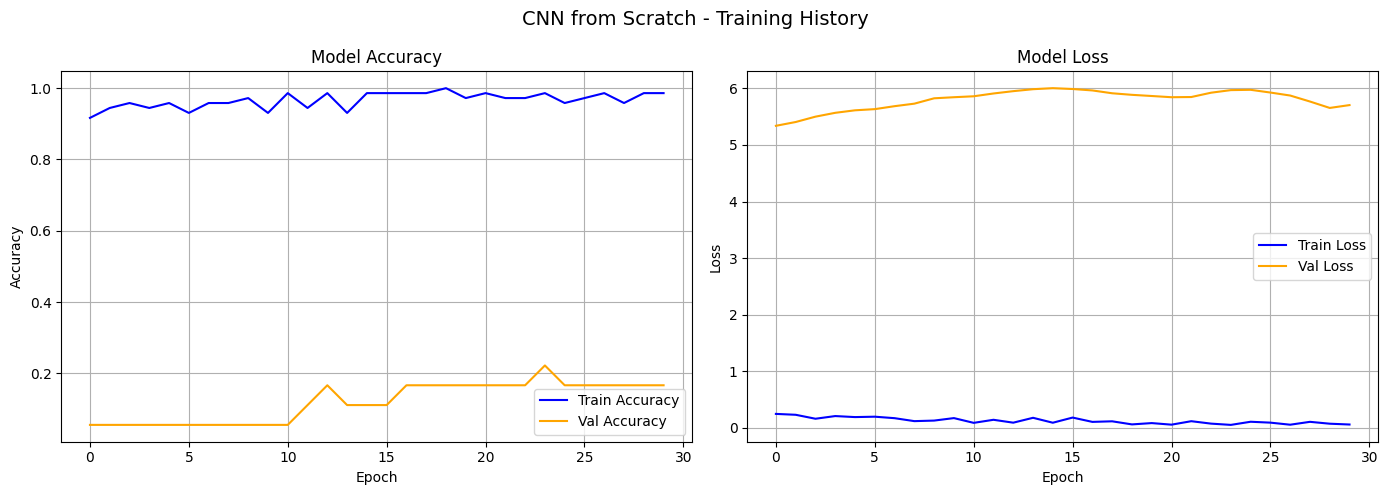

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN from Scratch - Training History', fontsize=14)
plt.tight_layout()
plt.show()

Evaluate and Save

In [27]:
# Evaluate
test_loss, test_acc = model.evaluate(val_ds, verbose=1)
print(f"\n{'='*40}")
print(f"Validation Loss     : {test_loss:.4f}")
print(f"Validation Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*40}")

# Save
model.save("cnn_fruits_scratch.keras")
print("\nModel saved as cnn_fruits_scratch.keras ✓")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - accuracy: 0.1667 - loss: 5.7036

Validation Loss     : 5.7036
Validation Accuracy : 0.1667 (16.67%)

Model saved as cnn_fruits_scratch.keras ✓


Transfer Learning with VGG16

 Load VGG16 Pre-trained Model

In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 without top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully ✓")
print(f"Total layers in VGG16: {len(base_model.layers)}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 loaded successfully ✓
Total layers in VGG16: 19


Freeze Base Model Layers

In [29]:
# Freeze all VGG16 layers
for layer in base_model.layers:
    layer.trainable = False

# Verify frozen layers
print("Layer Trainability Status:")
print("=" * 45)
for layer in base_model.layers:
    print(f"{layer.name:<30} Trainable: {layer.trainable}")
print("=" * 45)
print("All VGG16 layers frozen ✓")

Layer Trainability Status:
input_layer_3                  Trainable: False
block1_conv1                   Trainable: False
block1_conv2                   Trainable: False
block1_pool                    Trainable: False
block2_conv1                   Trainable: False
block2_conv2                   Trainable: False
block2_pool                    Trainable: False
block3_conv1                   Trainable: False
block3_conv2                   Trainable: False
block3_conv3                   Trainable: False
block3_pool                    Trainable: False
block4_conv1                   Trainable: False
block4_conv2                   Trainable: False
block4_conv3                   Trainable: False
block4_pool                    Trainable: False
block5_conv1                   Trainable: False
block5_conv2                   Trainable: False
block5_conv3                   Trainable: False
block5_pool                    Trainable: False
All VGG16 layers frozen ✓


Add Custom Classification Layers

In [30]:
# Take output from VGG16 base
x = base_model.output

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Fully Connected Layer
x = Dense(1024, activation='relu')(x)

# Output Layer — 6 fruit classes
output = Dense(num_classes, activation='softmax')(x)

print("Custom layers added ✓")

Custom layers added ✓


Create Final Model

In [31]:

vgg_model = Model(
    inputs=base_model.input,
    outputs=output
)

print("Final VGG16 model created ✓")
print(f"\nTotal layers    : {len(vgg_model.layers)}")
print(f"Trainable layers: {sum(1 for l in vgg_model.layers if l.trainable)}")
print(f"Frozen layers   : {sum(1 for l in vgg_model.layers if not l.trainable)}")

Final VGG16 model created ✓

Total layers    : 22
Trainable layers: 3
Frozen layers   : 19


View Model Summary

In [32]:
vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Compile the VGG16 Model

In [33]:
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 model compiled ✓")

VGG16 model compiled ✓


Train the VGG16 Model

In [34]:
EPOCHS = 30

vgg_history = vgg_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 25s/step - accuracy: 0.1667 - loss: 4.8643 - val_accuracy: 0.1111 - val_loss: 5.2562
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 22s/step - accuracy: 0.3472 - loss: 3.1153 - val_accuracy: 0.2222 - val_loss: 4.2653
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 21s/step - accuracy: 0.5139 - loss: 1.9621 - val_accuracy: 0.2778 - val_loss: 4.2061
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 25s/step - accuracy: 0.6111 - loss: 1.4635 - val_accuracy: 0.3333 - val_loss: 3.8642
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.7500 - loss: 1.0492 - val_accuracy: 0.3333 - val_loss: 3.2347
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.8750 - loss: 0.5665 - val_accuracy: 0.2778 - val_loss: 2.8569
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 17s/step - accuracy: 0.9028 - loss: 0.3789 - val_accuracy: 0.2778 - val_loss: 2.7138
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 22s/step - accuracy: 0.9028 - loss: 0.2511 - val_accuracy: 0.3333 - val_loss: 2.6261


Plot Training History

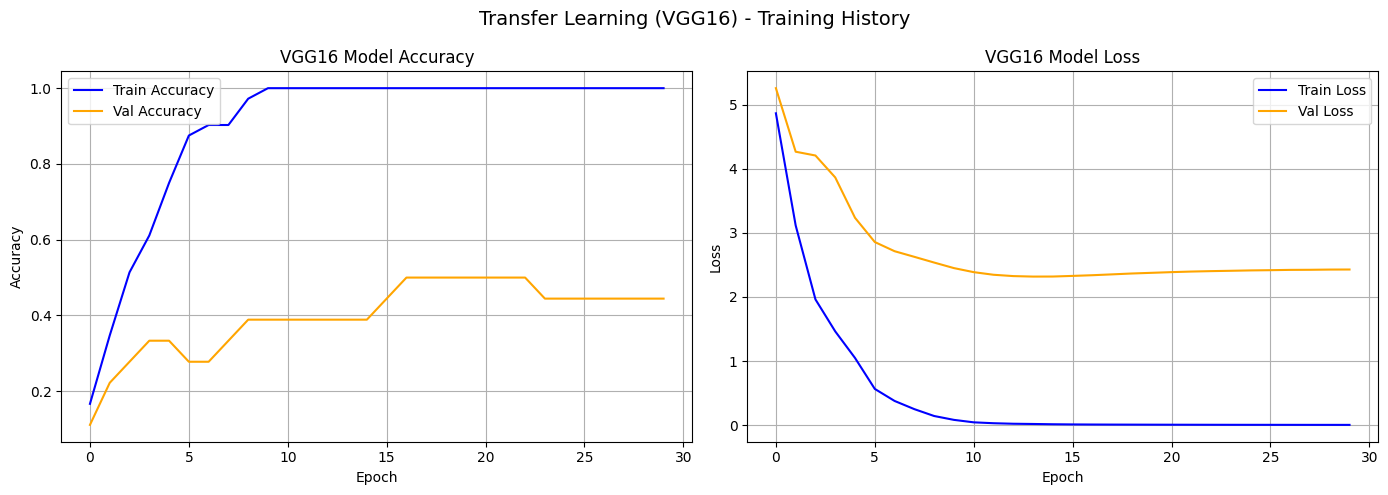

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(vgg_history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(vgg_history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('VGG16 Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(vgg_history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(vgg_history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('VGG16 Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Transfer Learning (VGG16) - Training History', fontsize=14)
plt.tight_layout()
plt.show()

Evaluate the Model

In [36]:
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds, verbose=1)

print(f"\n{'='*40}")
print(f"VGG16 Validation Loss     : {vgg_loss:.4f}")
print(f"VGG16 Validation Accuracy : {vgg_acc:.4f} ({vgg_acc*100:.2f}%)")
print(f"{'='*40}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.4444 - loss: 2.4285

VGG16 Validation Loss     : 2.4285
VGG16 Validation Accuracy : 0.4444 (44.44%)


Classification Report

In [42]:
import numpy as np
from sklearn.metrics import classification_report


vgg_pred = []
vgg_true = []

for images, labels in val_ds:
    preds = vgg_model.predict(images, verbose=0)

    predicted_labels = np.argmax(preds, axis=1)
    vgg_pred.extend(predicted_labels)

    if len(labels.shape) > 1:
        true_labels = np.argmax(labels.numpy(), axis=1)
    else:
        true_labels = labels.numpy()

    vgg_true.extend(true_labels)

vgg_pred = np.array(vgg_pred)
vgg_true = np.array(vgg_true)

print("\nClassification Report - VGG16")
print("=" * 60)

print(classification_report(
    vgg_true,
    vgg_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0,
    digits=4
))


Classification Report - VGG16
              precision    recall  f1-score   support

        acai     0.0000    0.0000    0.0000         3
     cupuacu     0.5000    0.7500    0.6000         4
    graviola     0.2500    1.0000    0.4000         1
     guarana     0.0000    0.0000    0.0000         1
     pupunha     0.6667    0.5000    0.5714         4
      tucuma     0.5000    0.4000    0.4444         5

    accuracy                         0.4444        18
   macro avg     0.3194    0.4417    0.3360        18
weighted avg     0.4120    0.4444    0.4060        18



Inference Output

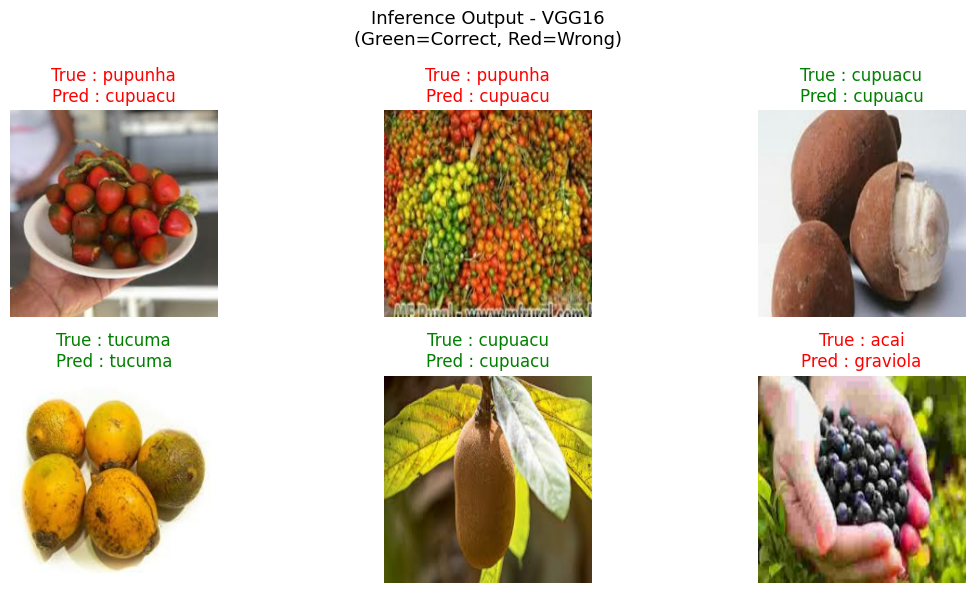


       MODEL PERFORMANCE COMPARISON
Model                      Accuracy      Loss
---------------------------------------------
CNN from Scratch             16.67%    5.7036
VGG16 Transfer Learning      44.44%    2.4285


In [39]:

plt.figure(figsize=(12, 6))

sample_images = []
sample_labels = []
sample_preds  = []

for images, labels in val_ds.take(1):
    preds = vgg_model.predict(images, verbose=0)
    for i in range(min(6, len(images))):
        sample_images.append(images[i].numpy().astype("uint8"))
        sample_labels.append(class_names[labels[i]])
        sample_preds.append(class_names[np.argmax(preds[i])])

for i in range(6):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])
    color = "green" if sample_preds[i] == sample_labels[i] else "red"
    plt.title(f"True : {sample_labels[i]}\nPred : {sample_preds[i]}", color=color)
    plt.axis("off")

plt.suptitle("Inference Output - VGG16\n(Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()


print("\n" + "="*45)
print("       MODEL PERFORMANCE COMPARISON")
print("="*45)
print(f"{'Model':<25}{'Accuracy':>10}{'Loss':>10}")
print("-"*45)
print(f"{'CNN from Scratch':<25}{test_acc*100:>9.2f}%{test_loss:>10.4f}")
print(f"{'VGG16 Transfer Learning':<25}{vgg_acc*100:>9.2f}%{vgg_loss:>10.4f}")
print("="*45)

Save VGG16 Model

In [40]:
vgg_model.save("vgg16_fruits_transfer.keras")
print("VGG16 model saved ✓")

VGG16 model saved ✓
